In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image, ImageFilter


Image.MAX_IMAGE_PIXELS = None
PROJECT_ROOT = Path("/home/irdorat/ML_comp")
ORIGINAL_PATH = PROJECT_ROOT / "data/test/01-PAN-20240420-113-325-L00000010882-CCD3_5_crop7.jpg"
MODEL_PATH = (
    PROJECT_ROOT / "models/pretrained/huggingface-cache"
    / "models--stable-diffusion-v1-5--stable-diffusion-inpainting"
    / "snapshots/8a4288a76071f7280aedbdb3253bdb9e9d5d84bb"
)

# Main controls.
CANVAS_SIZE = 10000                  # source dimensions
BACKGROUND_MODE = "sea"             # "sea" or "land"
SEED = 42

# Diffusion is used only beside the source, never across the full 10K image.
# Start with False for a strictly controlled object-free negative background.
USE_LOCAL_BOUNDARY_DIFFUSION = False
BOUNDARY_WINDOW = 512                
BOUNDARY_CONTEXT = 192               
BOUNDARY_OVERLAP = 192
BOUNDARY_STRENGTH = 0.52
BOUNDARY_STEPS = 40
GUIDANCE_SCALE = 4.0

# Deterministic radiometric transition outside the exact source.
TONAL_TRANSITION = 384
OUTPUT_PATH = PROJECT_ROOT / f"data/test/gen_image2_controlled_{CANVAS_SIZE}x{CANVAS_SIZE}.png"

if CANVAS_SIZE < 512:
    raise ValueError("CANVAS_SIZE must be at least 512")
if BOUNDARY_WINDOW % 8 or BOUNDARY_CONTEXT <= 0:
    raise ValueError("BOUNDARY_WINDOW must be divisible by 8 and context positive")
if BACKGROUND_MODE not in {"sea", "land"}:
    raise ValueError('BACKGROUND_MODE must be "sea" or "land"')

print("Canvas:", CANVAS_SIZE)
print("Mode:", BACKGROUND_MODE)
print("Local diffusion:", USE_LOCAL_BOUNDARY_DIFFUSION)
print("Output:", OUTPUT_PATH)

Canvas: 10000
Mode: sea
Local diffusion: False
Output: /home/irdorat/ML_comp/data/test/gen_image2_controlled_10000x10000.png


Original: (828, 828)
Placement: (9172, 0)
Estimated background mean/std: 68.0 5.58


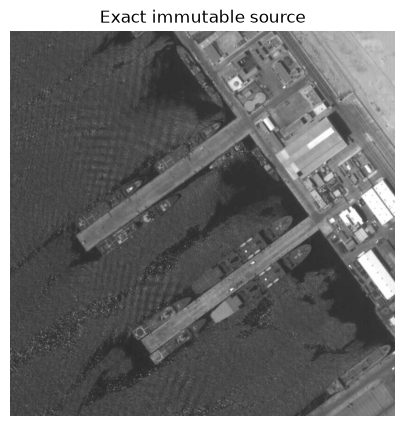

In [2]:
if not ORIGINAL_PATH.is_file():
    raise FileNotFoundError(ORIGINAL_PATH)

with Image.open(ORIGINAL_PATH) as source_file:
    original_image = source_file.convert("RGB").copy()

original_pixels = np.asarray(original_image).copy()
original_width, original_height = original_image.size
if original_width > CANVAS_SIZE or original_height > CANVAS_SIZE:
    raise ValueError(
        f"Source {original_image.size} does not fit canvas {CANVAS_SIZE}×{CANVAS_SIZE}"
    )

# Exact placement: upper-right, without resize.
offset_x = CANVAS_SIZE - original_width
offset_y = 0
source_box = (offset_x, 0, CANVAS_SIZE, original_height)

# Estimate background tone from dark boundary pixels only. This transfers no
# structures or objects from the source—only scalar luminance statistics.
gray_source = np.asarray(original_image.convert("L"), dtype=np.float32)
strip = max(24, min(original_width, original_height) // 16)
boundary_samples = np.concatenate([
    gray_source[:, :strip].ravel(),
    gray_source[-strip:, :].ravel(),
])
threshold = np.percentile(boundary_samples, 55 if BACKGROUND_MODE == "sea" else 75)
selected = boundary_samples[boundary_samples <= threshold]
target_mean = float(np.clip(np.median(selected), 32, 150))
target_std = float(np.clip(np.std(selected), 5, 22))

print("Original:", original_image.size)
print("Placement:", (offset_x, offset_y))
print("Estimated background mean/std:", round(target_mean, 2), round(target_std, 2))

plt.figure(figsize=(5, 5))
plt.imshow(original_image, cmap="gray")
plt.title("Exact immutable source")
plt.axis("off")
plt.show()

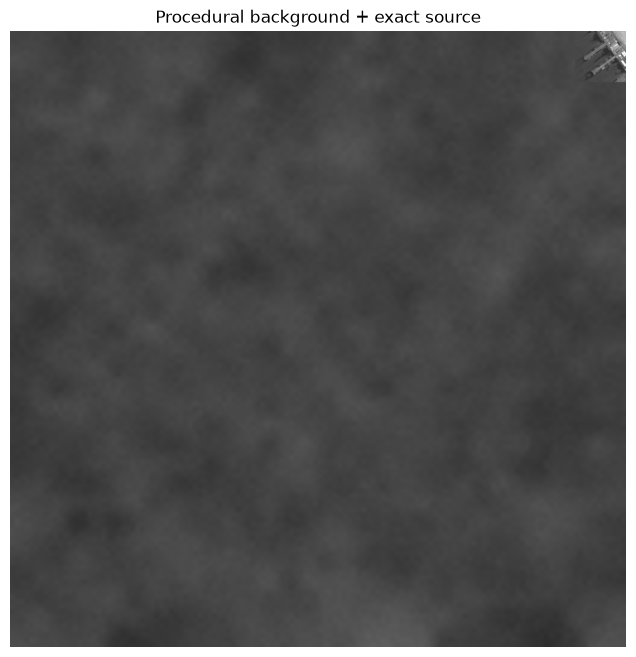

In [3]:
def resized_noise(size, coarse_size, rng, blur=0):
    coarse = rng.normal(127.5, 38.0, (coarse_size, coarse_size))
    layer = Image.fromarray(np.clip(coarse, 0, 255).astype(np.uint8), mode="L")
    layer = layer.resize((size, size), Image.Resampling.BICUBIC)
    if blur:
        layer = layer.filter(ImageFilter.GaussianBlur(blur))
    return np.asarray(layer, dtype=np.float32) - 127.5


def make_procedural_background(size, mean, std, seed, mode="sea"):
    """Object-free non-periodic texture with bounded memory for a 10K canvas."""
    rng = np.random.default_rng(seed)
    # Build semantics at a compact resolution. Upscaling smooth noise introduces
    # no copied objects, tiles or periodic patches and avoids multi-GB arrays.
    work_size = min(size, 2048)
    low = resized_noise(work_size, max(12, work_size // 256), rng, blur=2)
    mid = resized_noise(work_size, max(32, work_size // 64), rng, blur=1)
    fine = resized_noise(work_size, max(96, work_size // 16), rng)
    texture = 0.58 * low + 0.30 * mid + 0.12 * fine

    if mode == "sea":
        y, x = np.mgrid[0:work_size, 0:work_size].astype(np.float32)
        for wavelength, amplitude in ((180.0, 0.8), (73.0, 0.45)):
            phase = rng.uniform(0, 2 * np.pi)
            slope = rng.uniform(0.08, 0.22)
            texture += amplitude * np.sin(
                2 * np.pi * (x + slope * y) / wavelength + phase
            )

    texture -= float(texture.mean())
    texture *= std / max(float(texture.std()), 1e-6)
    compact = Image.fromarray(
        np.clip(texture + mean, 0, 255).astype(np.uint8), mode="L"
    )
    if work_size != size:
        compact = compact.resize((size, size), Image.Resampling.BICUBIC)
    return compact.convert("RGB")

background = make_procedural_background(
    CANVAS_SIZE, target_mean, target_std, SEED, BACKGROUND_MODE
)
working_image = background.copy()
working_image.paste(original_image, (offset_x, offset_y))

preview = working_image.resize((900, 900), Image.Resampling.LANCZOS)
plt.figure(figsize=(8, 8))
plt.imshow(preview)
plt.title("Procedural background + exact source")
plt.axis("off")
plt.show()

In [4]:
def axis_starts(length, window, overlap):
    if length <= window:
        return [0]
    step = window - overlap
    starts = list(range(0, length - window + 1, step))
    if starts[-1] != length - window:
        starts.append(length - window)
    return starts


def local_boundary_boxes():
    """Only windows crossing source left and bottom edges; no 10K tiling."""
    boxes = []
    # Vertical source boundary.
    left = max(0, min(offset_x - BOUNDARY_CONTEXT, CANVAS_SIZE - BOUNDARY_WINDOW))
    for local_top in axis_starts(original_height, BOUNDARY_WINDOW, BOUNDARY_OVERLAP):
        boxes.append((left, local_top, left + BOUNDARY_WINDOW, local_top + BOUNDARY_WINDOW))
    # Horizontal source boundary.
    top = max(0, min(original_height - (BOUNDARY_WINDOW - BOUNDARY_CONTEXT), CANVAS_SIZE - BOUNDARY_WINDOW))
    for local_left in axis_starts(original_width, BOUNDARY_WINDOW, BOUNDARY_OVERLAP):
        x = offset_x + local_left
        x = max(0, min(x, CANVAS_SIZE - BOUNDARY_WINDOW))
        boxes.append((x, top, x + BOUNDARY_WINDOW, top + BOUNDARY_WINDOW))
    return list(dict.fromkeys(boxes))


if USE_LOCAL_BOUNDARY_DIFFUSION:
    from diffusers import StableDiffusionInpaintPipeline

    if not MODEL_PATH.is_dir():
        raise FileNotFoundError(MODEL_PATH)
    if not torch.cuda.is_available():
        raise RuntimeError("CUDA is required for local boundary diffusion")

    pipe = StableDiffusionInpaintPipeline.from_pretrained(
        MODEL_PATH, variant="fp16", torch_dtype=torch.float16,
        use_safetensors=True, local_files_only=True,
        safety_checker=None, requires_safety_checker=False,
    )
    pipe.enable_model_cpu_offload()
    pipe.vae.enable_tiling()

    prompt = (
        f"panchromatic satellite photograph, strict vertical nadir view, "
        f"continuous object-free {BACKGROUND_MODE}, same scale, exposure and illumination, "
        "natural subtle texture, empty background"
    )
    negative = (
        "ship, boat, vehicle, aircraft, building, harbor, pier, road, cable, pipeline, "
        "island, new object, bright line, geometric shape, rectangle, frame, collage, text"
    )

    for index, box in enumerate(local_boundary_boxes()):
        tile = working_image.crop(box)
        x0, y0, x1, y1 = box
        yy, xx = np.mgrid[y0:y1, x0:x1]
        inside_source = (
            (xx >= offset_x) & (xx < CANVAS_SIZE) &
            (yy >= 0) & (yy < original_height)
        )
        # White means regenerate exterior; source pixels remain black/protected.
        mask_array = np.where(inside_source, 0, 255).astype(np.uint8)
        mask = Image.fromarray(mask_array, mode="L").filter(ImageFilter.GaussianBlur(8))

        generator = torch.Generator(device="cpu").manual_seed(SEED + 1000 + index)
        with torch.inference_mode():
            generated = pipe(
                prompt=prompt, negative_prompt=negative,
                image=tile, mask_image=mask,
                width=BOUNDARY_WINDOW, height=BOUNDARY_WINDOW,
                strength=BOUNDARY_STRENGTH,
                num_inference_steps=BOUNDARY_STEPS,
                guidance_scale=GUIDANCE_SCALE,
                generator=generator,
            ).images[0].convert("L").convert("RGB")

        # Paste generated exterior only; source is never accepted from the model.
        exact_exterior_mask = Image.fromarray(
            np.where(inside_source, 0, 255).astype(np.uint8), mode="L"
        )
        composed = Image.composite(generated, tile, exact_exterior_mask)
        working_image.paste(composed, (x0, y0))
        working_image.paste(original_image, (offset_x, offset_y))
        print(f"Boundary window {index + 1}: {box}")
else:
    print("Local boundary diffusion disabled: deterministic background retained")

Local boundary diffusion disabled: deterministic background retained


In [5]:
def smooth_1d_vectors(values, radius=20):
    radius = min(radius, max(1, len(values) // 4))
    kernel = np.ones(2 * radius + 1, dtype=np.float32)
    kernel /= kernel.sum()
    padded = np.pad(values, ((radius, radius), (0, 0)), mode="edge")
    return np.stack([
        np.convolve(padded[:, channel], kernel, mode="valid")
        for channel in range(3)
    ], axis=1)


def match_exterior_boundaries(image, source, transition):
    """Correct only narrow exterior strips; never allocate a float 10K RGB array."""
    result = image.copy()
    src = np.asarray(source, dtype=np.float32)
    h, w, _ = src.shape

    if offset_x > 0:
        width = min(transition, offset_x)
        box = (offset_x - width, 0, offset_x, h)
        strip = np.asarray(result.crop(box), dtype=np.float32).copy()
        delta = smooth_1d_vectors(src[:, 0] - strip[:, -1])
        distances = np.arange(width - 1, -1, -1, dtype=np.float32)
        t = distances / max(width - 1, 1)
        weights = 0.5 * (1.0 + np.cos(np.pi * t))
        strip += delta[:, None, :] * weights[None, :, None]
        result.paste(
            Image.fromarray(np.clip(strip, 0, 255).astype(np.uint8), mode="RGB"),
            (offset_x - width, 0),
        )

    if h < CANVAS_SIZE:
        height = min(transition, CANVAS_SIZE - h)
        box = (offset_x, h, offset_x + w, h + height)
        strip = np.asarray(result.crop(box), dtype=np.float32).copy()
        delta = smooth_1d_vectors(src[-1] - strip[0])
        distances = np.arange(height, dtype=np.float32)
        t = distances / max(height - 1, 1)
        weights = 0.5 * (1.0 + np.cos(np.pi * t))
        strip += delta[None, :, :] * weights[:, None, None]
        result.paste(
            Image.fromarray(np.clip(strip, 0, 255).astype(np.uint8), mode="RGB"),
            (offset_x, h),
        )

    result.paste(source, (offset_x, 0))
    return result

final_image = match_exterior_boundaries(
    working_image, original_image, TONAL_TRANSITION
)
# Final unconditional pixel-perfect restoration.
final_image.paste(original_image, (offset_x, 0))

OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
final_image.save(OUTPUT_PATH, format="PNG", compress_level=2)

with Image.open(OUTPUT_PATH) as saved_file:
    saved_file.load()
    saved_source = saved_file.convert("RGB").crop(source_box)

saved_pixels = np.asarray(saved_source)
absolute_difference = np.abs(
    saved_pixels.astype(np.int16) - original_pixels.astype(np.int16)
)
assert np.array_equal(saved_pixels, original_pixels), "Original source pixels changed"

print("Saved:", OUTPUT_PATH)
print("Original pixels unchanged: True")
print("Maximum source difference:", int(absolute_difference.max()))

Saved: /home/irdorat/ML_comp/data/test/gen_image2_controlled_10000x10000.png
Original pixels unchanged: True
Maximum source difference: 0


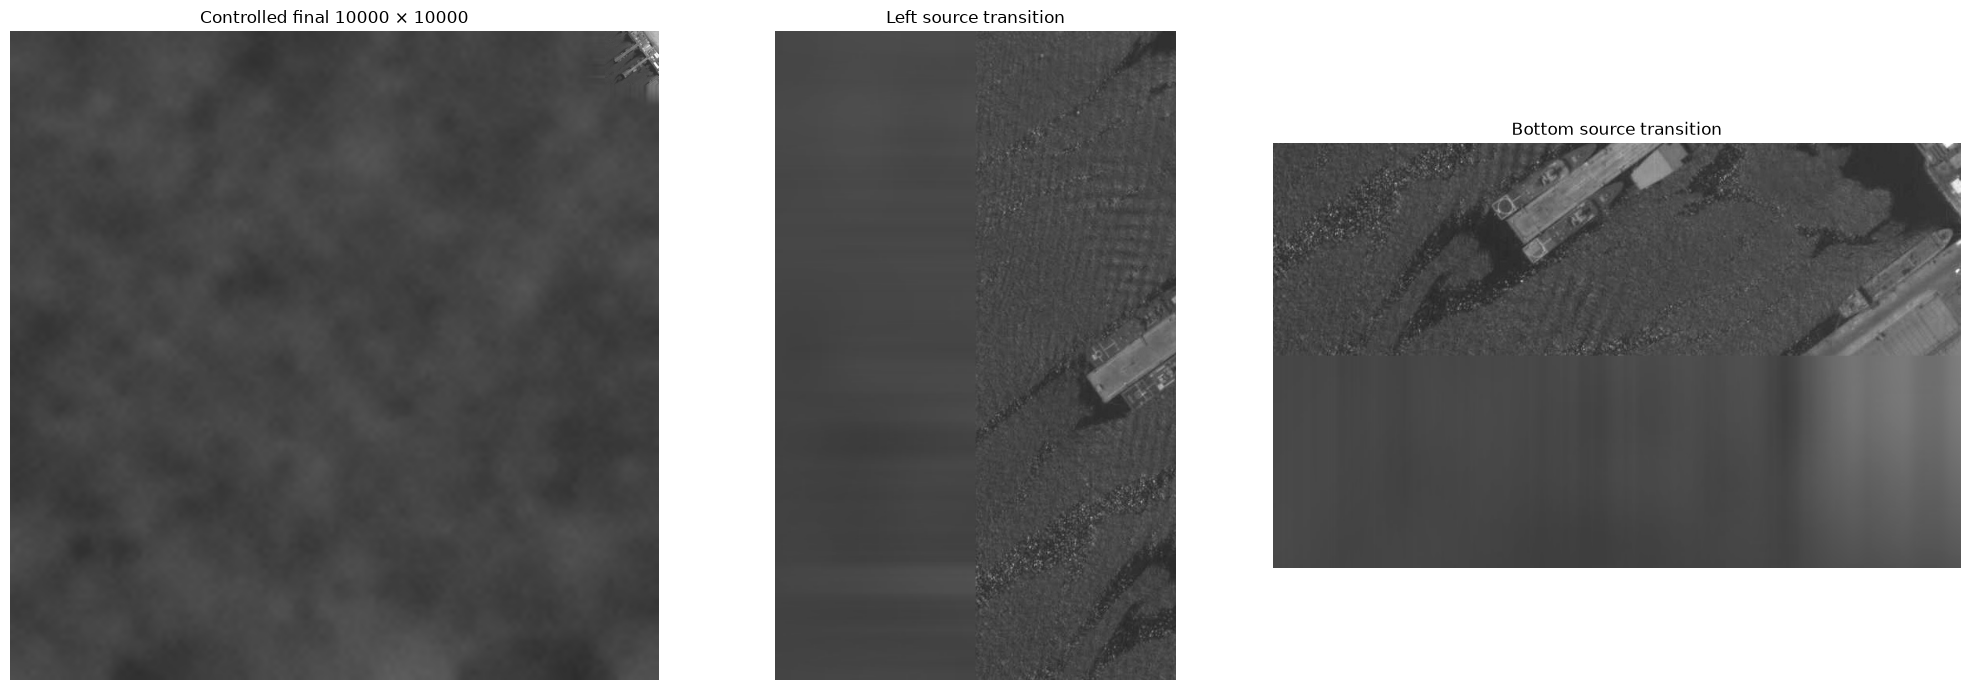

In [6]:
preview_size = min(1200, CANVAS_SIZE)
preview = final_image.resize((preview_size, preview_size), Image.Resampling.LANCZOS)
band = min(256, offset_x, CANVAS_SIZE - original_height)
left_boundary = final_image.crop((offset_x - band, 0, offset_x + band, original_height))
bottom_boundary = final_image.crop((offset_x, original_height - band, CANVAS_SIZE, original_height + band))

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
axes[0].imshow(preview)
axes[0].set_title(f"Controlled final {CANVAS_SIZE} × {CANVAS_SIZE}")
axes[1].imshow(left_boundary)
axes[1].set_title("Left source transition")
axes[2].imshow(bottom_boundary)
axes[2].set_title("Bottom source transition")
for axis in axes:
    axis.axis("off")
plt.tight_layout()
plt.show()